In [1]:
import numpy as np
import scipy.integrate as spi
import scipy.optimize as spo
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import os
import pickle

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
})

In [2]:
def read_pdf_theta(directory, fixed_cof, fixed_I, aspect_ratios):
    
    current_directory = os.getcwd()
    if current_directory.endswith(directory):
        pass
    else:
        os.chdir(directory)
    #initilize data list
    nematic_parameter = np.zeros(len(aspect_ratios))
    biaxiality = np.zeros(len(aspect_ratios))
    theta_d = np.zeros(len(aspect_ratios))
    phi = np.zeros(len(aspect_ratios))
    bin_centers = np.zeros((len(aspect_ratios), 100))
    pdf_data = np.zeros((len(aspect_ratios), 100)) 
    U_fitted = np.zeros(len(aspect_ratios))
    phi_fluctuations = np.zeros(len(aspect_ratios))
    D_r = np.zeros(len(aspect_ratios))
    shear_rate = np.zeros(len(aspect_ratios))
    rmse = np.zeros(len(aspect_ratios))
    n1_diff = np.zeros(len(aspect_ratios))
    n2_diff = np.zeros(len(aspect_ratios))
    p_yy = np.zeros(len(aspect_ratios))
    p_xy = np.zeros(len(aspect_ratios))
    S2_tensor = np.zeros((len(aspect_ratios), 3, 3))
    S4_tensor = np.zeros((len(aspect_ratios), 3, 3, 3, 3))
    strains = np.zeros((len(aspect_ratios), 3200))
    S2_over_time = np.zeros((len(aspect_ratios), 3200))
    times = np.zeros((len(aspect_ratios), 510))
    oacf = np.zeros((len(aspect_ratios), 510))
    tau_r = np.zeros(len(aspect_ratios))
    A_infty = np.zeros(len(aspect_ratios))
    omega = np.zeros(len(aspect_ratios))

    for idx, ap in enumerate(aspect_ratios):
        filename = f'orientation_simple_shear_ap{ap}_cof_{fixed_cof}_I_{fixed_I}.pkl'
        if os.path.exists(filename):
            with open(filename, 'rb') as file:
                file_data = pickle.load(file)
                bin_centers[idx, :] = file_data['bin_centers']
                pdf_data[idx, :] = file_data['f_data']
                nematic_parameter[idx] = file_data['nematic_order_parameter']
                biaxiality[idx] = file_data['biaxiality']
                theta_d[idx] = file_data['theta_d']
                U_fitted[idx] = file_data['U_fitted']
                phi[idx] = file_data['phi']
                phi_fluctuations[idx] = file_data['phi_fluct']
                D_r[idx] = file_data['D_r']
                shear_rate[idx] = file_data['shear_rate']
                rmse[idx] = file_data['rmse_fit']
                n1_diff[idx] = file_data['Nx_diff']
                n2_diff[idx] = file_data['Nz_diff']
                p_yy[idx] = file_data['p_yy']
                p_xy[idx] = file_data['p_xy']
                S2_tensor[idx, :, :] = file_data['nematic_tensor']
                S4_tensor[idx, :, :, :, :] = file_data['S4']
                strains[idx, :len(file_data['strains'])] = file_data['strains'] # zeros in the end
                S2_over_time[idx, :len(file_data['strains'])] = file_data['S2_over_time']
                times[idx, :len(file_data['times'])] = file_data['times']
                oacf[idx, :len(file_data['times'])] = file_data['oacf']
                tau_r[idx] = file_data['tau_r']
                A_infty[idx] = file_data['A_infty']


    os.chdir('..') # return to the original directory
    return (bin_centers, pdf_data, nematic_parameter, biaxiality, theta_d, U_fitted,
             phi, phi_fluctuations, D_r, shear_rate, rmse, n1_diff, n2_diff, p_yy, p_xy,
               S2_tensor, S4_tensor, strains, S2_over_time, times, oacf, tau_r, A_infty)

def fit_equilibrium_ODF(measured_thetas, S, U):
    """
    Maier-Saupe equilibrium distribution per unit solid angle,
    accounting for head-tail symmetry (θ ∈ [0, π/2]).
    Normalization is computed over [0, π/2] and multiplied by 2 to account for symmetry.
    """
    numerator = np.exp(S * U * np.cos(2 * measured_thetas))
    integrand = numerator * np.sin(measured_thetas)
    denominator =  4 * np.pi * np.trapezoid(integrand, x=measured_thetas)
    return numerator / denominator

def pi_formatter(x, pos):
    frac = x / np.pi
    if np.isclose(frac, 0): return "0"
    elif np.isclose(frac, 1): return r"$\pi$"
    elif np.isclose(frac, 0.5): return r"$\pi/2$"
    else: return fr"${frac:.2f}\pi$"

Number of colors: 8, Length of colormap: 256, Delta color: 36.0


/tmp/ipykernel_10131/2686955186.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


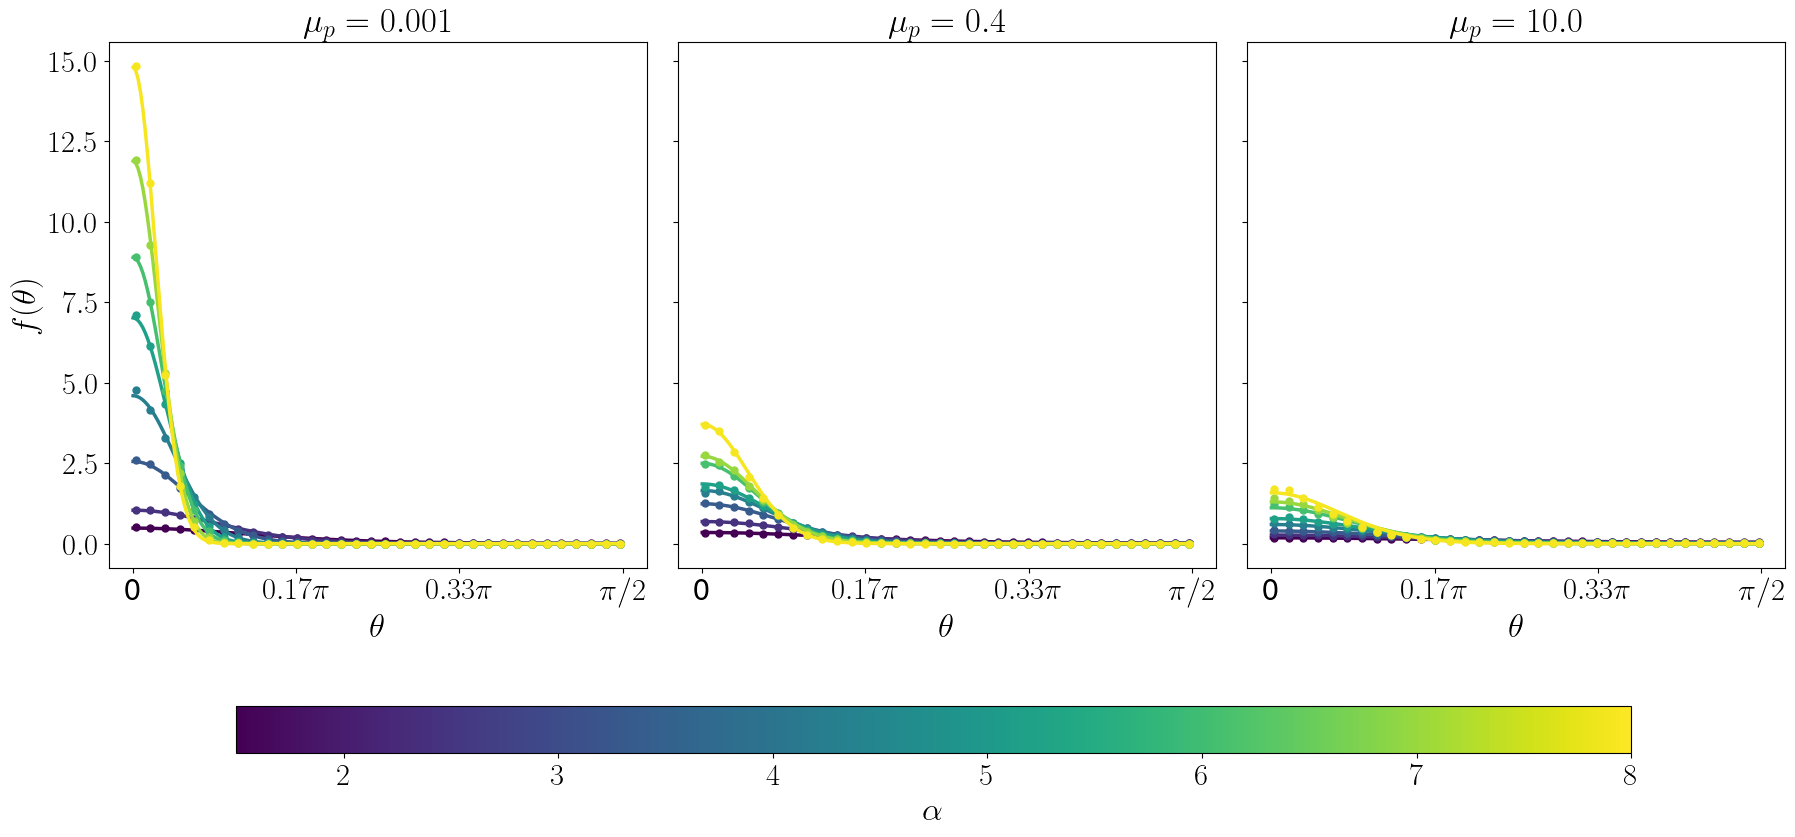

In [3]:
aspect_ratios = np.array([1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0])

directory = "output_data_hertz"
# cof = 0.0
# I = 0.1
# (bin_centers, pdf_data, nematic_parameter, biaxiality, theta_d, U_fitted,
#   phi, phi_fluctuations, D_r, shear_rate, rsme,
#     n1_diff, n2_diff, p_yy, p_xy, S2_tensor, S4_tensor, 
#     strains, S2_over_time, times, oacf) = read_pdf_theta(directory, cof, I, aspect_ratios)


thetas = np.linspace(0, np.pi / 2, 200)
cmap = plt.cm.viridis
num_colors = len(aspect_ratios)
length_cmap = cmap.N
delta_color = np.floor(length_cmap / (num_colors-1))
print(f"Number of colors: {num_colors}, Length of colormap: {length_cmap}, Delta color: {delta_color}")
# assign colors to each aspect ratio
colors = [cmap(i*int(delta_color)) for i in range(num_colors)]

I=0.1
cofs = [0.001, 0.4, 10.0]
num_cofs = len(cofs)
fig, axes = plt.subplots(1, num_cofs, figsize=(6 * num_cofs, 6), sharey=True)
plt.rc('font', size=14)          # controls default text sizes
plt.rc('axes', titlesize=14)     # fontsize of the axes title
plt.rc('axes', labelsize=14)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=12)    # fontsize of the tick labels
plt.rc('ytick', labelsize=12)    # fontsize of the tick labels
plt.rc('legend', fontsize=14)    # legend fontsize
plt.rc('figure', titlesize=18)   # fontsize of the figure title
for ax, cof in zip(axes, cofs):
    # Read data for the current coefficient of friction
    (bin_centers, pdf_data, nematic_parameter, biaxiality, 
     theta_d, U_fitted, phi, phi_fluctuations, D_r, shear_rate,
       rmse, n1_diff, n2_diff, p_yy, p_xy, S2_tensor, S4_tensor, 
       strains, S2_over_time, times, oacf, tau_r, A_infty)  = read_pdf_theta(directory, cof, I, aspect_ratios)
    for i, ap in enumerate(aspect_ratios):
        fitted_odf = fit_equilibrium_ODF(thetas, nematic_parameter[i], U_fitted[i])

        # Plot fitted ODF and PDF data
        ax.plot(thetas, fitted_odf, label=f'$\\alpha={ap}$', linestyle='-', linewidth=2.5, color=colors[i])
        ax.plot(bin_centers[i, ::3], pdf_data[i, ::3], 'o', linestyle='', markersize=5, color=colors[i])

    ax.set_xlabel('$\\theta$', fontsize=24)
    ax.set_title(f'$\\mu_p = {cof}$', fontsize=25)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(np.pi / 6))
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(pi_formatter))
# ax.legend(fontsize=20, bbox_to_anchor=(1.05, 1.0), loc='upper left', ncol=1)

# Normalize aspect_ratios (alpha values) to [0, 1] range for colormap
norm = mcolors.Normalize(vmin=min(aspect_ratios), vmax=max(aspect_ratios))
sm = cm.ScalarMappable(cmap='viridis', norm=norm)  # use your same colormap
sm.set_array([])  # Needed only for matplotlib < 3.1

# Add colorbar above the subplots
cbar = plt.colorbar(sm, ax=axes, orientation='horizontal', fraction=0.3,  aspect=30, anchor=(0.5, -2.5))
cbar.set_label(r'$\alpha$', fontsize=24)
cbar.ax.tick_params(labelsize=22)

# Set common Y label
axes[0].set_ylabel('$f(\\theta)$', fontsize=24)

# Make all tick labels larger
for ax in axes:
    ax.tick_params(axis='both', labelsize=22)

plt.tight_layout()
plt.savefig(f"pdf_comparison_Is_{I}.png", dpi=300, bbox_inches='tight')
plt.show()

In [4]:
cofs = [0.0, 0.001, 0.01, 0.1, 0.4, 1.0, 10.0]
Is = [0.001, 0.0046, 0.0022, 0.01, 0.046, 0.022, 0.1]
aspect_ratios = np.array([1.2, 1.5, 1.8, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 7.0, 8.0])
# cofs=[0.0, 0.001]
Is=[0.1]


biaxiality = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
nematic_parameter = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
theta_d = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
U_fitted = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
phis = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
phi_fluctuations = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
D_r = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
shear_rates = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
rmse = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
n1_diff = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
n2_diff = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
p_yy = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
p_xy = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
S2_tensor = np.zeros((len(cofs), len(Is), len(aspect_ratios), 3, 3))
S4_tensor = np.zeros((len(cofs), len(Is), len(aspect_ratios), 3, 3, 3, 3))
# Initialize arrays to store strains, S2_over_time, times, and oacf
strains = np.zeros((len(cofs), len(Is), len(aspect_ratios), 3200))
S2_over_time = np.zeros((len(cofs), len(Is), len(aspect_ratios), 3200))
times = np.zeros((len(cofs), len(Is), len(aspect_ratios), 510))
oacf = np.zeros((len(cofs), len(Is), len(aspect_ratios), 510))
tau_r = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
A_infty = np.zeros((len(cofs), len(Is), len(aspect_ratios)))


for i_cof, fixed_cof in enumerate(cofs):
    for i_I, fixed_I in enumerate(Is):
        (bin_centers, pdf_data, nematic_parameter_temp, biaxiality_temp, theta_d_temp,
          U_fitted_temp, phi_temp, phi_fluct_temp, D_r_temp, shear_rate_temp, 
          rmse_temp, n1_diff_temp, n2_diff_temp, p_yy_temp, p_xy_temp, 
          S2_tensor_temp, S4_tensor_temp, 
          strains_temp, S2_over_time_temp, times_temp, oacf_temp, tau_r_temp, A_infty_temp
          ) = read_pdf_theta(directory, fixed_cof, fixed_I, aspect_ratios)
        
        for i_alpha in range(len(aspect_ratios)):
            biaxiality[i_cof, i_I, i_alpha] = biaxiality_temp[i_alpha]
            nematic_parameter[i_cof, i_I, i_alpha] = nematic_parameter_temp[i_alpha]
            theta_d[i_cof, i_I, i_alpha] = theta_d_temp[i_alpha]
            U_fitted[i_cof, i_I, i_alpha] = U_fitted_temp[i_alpha]
            phis[i_cof, i_I, i_alpha] = phi_temp[i_alpha]
            phi_fluctuations[i_cof, i_I, i_alpha] = phi_fluct_temp[i_alpha]
            D_r[i_cof, i_I, i_alpha] = D_r_temp[i_alpha]
            shear_rates[i_cof, i_I, i_alpha] = shear_rate_temp[i_alpha]
            rmse[i_cof, i_I, i_alpha] = rmse_temp[i_alpha]
            n1_diff[i_cof, i_I, i_alpha] = n1_diff_temp[i_alpha]
            n2_diff[i_cof, i_I, i_alpha] = n2_diff_temp[i_alpha]
            p_yy[i_cof, i_I, i_alpha] = p_yy_temp[i_alpha]
            p_xy[i_cof, i_I, i_alpha] = p_xy_temp[i_alpha]
            S2_tensor[i_cof, i_I, i_alpha, :, :] = S2_tensor_temp[i_alpha, :, :]
            S4_tensor[i_cof, i_I, i_alpha, :, :, :, :] = S4_tensor_temp[i_alpha, :, :, :, :]
            strains[i_cof, i_I, i_alpha, :len(strains_temp[i_alpha])] = strains_temp[i_alpha]
            S2_over_time[i_cof, i_I, i_alpha, :len(S2_over_time_temp[i_alpha])] = S2_over_time_temp[i_alpha]
            times[i_cof, i_I, i_alpha, :len(times_temp[i_alpha])] = times_temp[i_alpha]
            oacf[i_cof, i_I, i_alpha, :len(oacf_temp[i_alpha])] = oacf_temp[i_alpha]
            tau_r[i_cof, i_I, i_alpha] = tau_r_temp[i_alpha]
            A_infty[i_cof, i_I, i_alpha] = A_infty_temp[i_alpha]
            

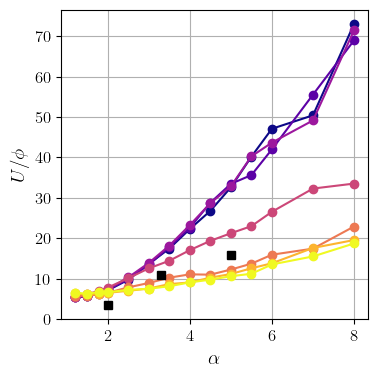

In [5]:
# plot the biaxiality as a function of aspect ratio for different cof and Is
cmap = plt.cm.plasma
num_cofs = len(cofs)

U_experimental = np.array([1.2512, 4.108, 5.747]) # the factor 4/3 takes into account the fact I fitted directly p_2
alpha_experimental= np.array([2.0, 3.3, 5.0])
phi_experimental = np.array([0.495, 0.5, 0.48])
S2_experimental = np.array([0.27, 0.72, 0.81])

for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(4,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    eccentricity = np.sqrt(1 - 1 / aspect_ratios**2)   
    volume = 4*np.pi*aspect_ratios/3 
   
    for i_cof, cof_val in enumerate(cofs):
        phi_dense = phis[i_cof, i_I, :] 
        plt.plot(
            # eccentricity,
            aspect_ratios,
            U_fitted[i_cof, i_I, :]/phi_dense,
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='o'
        )

        # fir alpha **2parabola
        def parabola_fit(alpha, a, b, c):
            return a * alpha**b + c

    plt.plot(
        alpha_experimental,
        4/3*U_experimental/phi_experimental,
        's',
        label='Experimental data',
        color='black'
    )

    # plt.title(f"U_fitted vs epsilon for I = {I_val}")
    plt.xlabel(f"$\\alpha$")
    # plt.ylabel("$U V_p / 2 \\phi \\alpha^2$")#\\phi$")
    # plt.ylabel("$U  / (\\eta(\\phi) V_{{excl}}) $")#\\phi$")
    plt.ylabel("$U  / \\phi $")#\\phi$")
    # plt.xlim(0.7, 1.0)
    # plt.axhline(1.0, color='k', linestyle='--', linewidth=1.5, label="Excluded volume")
    # plt.ylim(0, 2)
    # plt.xlim(1.5, 6.0)
    # plt.legend(title="$\\mu_p=$", bbox_to_anchor=(1.4, 0.5), fontsize=10)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"U_fitted_vs_alpha_I_{I_val}_unscaled.png", dpi=300, bbox_inches='tight')
    plt.show()

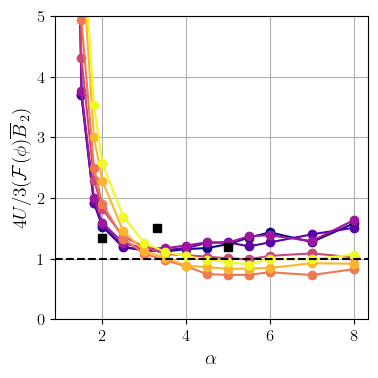

In [6]:
def second_coeff_excluded_volume(x):
    first_factor = 15 / 32 / x**4
    second_factor = x**2 - 3 + (x**2+3) * (1- x**2) * np.arctanh(x) / x
    third_factor = 3 - 2 * x**2 + (4 * x**2 - 3)*np.arcsin(x) / (x * np.sqrt(1 - x**2))
    return first_factor * second_factor * third_factor

def parsons_volume_approx(alpha):
    chi = (alpha**2 - 1) / (alpha**2 + 1)
    first_term = 8 /3 * chi**2
    second_term = 1/np.sqrt(1-chi**2)
    third_term = 1+3*chi**2/14
    return first_term * second_term * third_term

def excluded_volume_rod(alpha):
    second_coeff_A_complete = -5 /32 *np.pi *  (8*alpha / np.pi +2/alpha)
    # second_coeff_A_complete = 16 * alpha / (3*np.pi) 
    second_coeff_B_complete = 5/4
    second_coeff_C_complete = 0.385*8/np.pi

    return (second_coeff_A_complete +second_coeff_B_complete + second_coeff_C_complete)


for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(4,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    eccentricity = np.sqrt(1 - 1 / aspect_ratios**2)   
    volume = 4*np.pi*aspect_ratios/3 
    # volume_excluded = -second_coeff_excluded_volume(eccentricity)
    volume_excluded = parsons_volume_approx(aspect_ratios)

    for i_cof, cof_val in enumerate(cofs):
        phi_dense = phis[i_cof, i_I, :] 
        number_density = phi_dense / volume
        correction_density = phi_dense*(1-3/4*phi_dense) / (1-phi_dense)**2
        # correction_density = phi_dense/24 *(4*phi_dense**2 - 33*phi_dense+34) / (1-phi_dense)**2
        plt.plot(
            # eccentricity,
            aspect_ratios,
            # U_fitted[i_cof, i_I, :]/phi_dense,
            # U_fitted[i_cof, i_I, :]  / (2* 4/np.pi* aspect_ratios * phi_dense,
            U_fitted[i_cof, i_I, :] /(3/4*volume_excluded*correction_density), #factor 3/4 accounts for the use of cos(2*theta) instead of P_2(cos(theta))
            # U_fitted[i_cof, i_I, :] /(volume_excluded* phi_dense), 
            # U_fitted[i_cof, i_I, :] ,
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='o'
        )

    
    correction_density_experimental = phi_experimental * (1-3/4*phi_experimental) / (1-phi_experimental)**2
    volume_excluded_experimental = -excluded_volume_rod(alpha_experimental)
    plt.plot(
        alpha_experimental,
        U_experimental / (volume_excluded_experimental * correction_density_experimental),
        's',
        label='Experimental data',
        color='black'
    )

    # plt.title(f"U_fitted vs epsilon for I = {I_val}")
    plt.xlabel(f"$\\alpha$")
    # plt.ylabel("$U V_p / 2 \\phi \\alpha^2$")#\\phi$")
    plt.ylabel("$4U  / 3(\\mathcal{{F}}(\\phi) \\overline{{B}}_{{2}}) $")#\\phi$")
    # plt.ylabel("$U  / \\phi) $")#\\phi$")
    # plt.xlim(0.7, 1.0)
    plt.axhline(1.0, color='k', linestyle='--', linewidth=1.5, label="Excluded volume")
    # plt.axhline(0.5, color='k', linestyle='--', linewidth=1.5, label="Excluded volume/2")
    plt.ylim(0, 5.0)
    # plt.xlim(1.5, 10.0)
    # plt.legend(title="$\\mu_p=$", bbox_to_anchor=(1.4, 1.1), fontsize=10)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"U_fitted_vs_alpha_I_{I_val}_scaled.png", dpi=300, bbox_inches='tight')
    plt.show()

In [7]:
import matplotlib.pyplot as plt


# Color map for different aspect ratios
cmap = plt.cm.viridis
num_alphas = len(aspect_ratios)
colors = [cmap(i / (num_alphas - 1)) for i in range(num_alphas)]

# Plot for each I
for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(8, 6))

    for i_alpha, alpha_val in enumerate(aspect_ratios):
        correction_density = phis[:, i_I, i_alpha] * (1 - 3 / 4 * phis[:, i_I, i_alpha]) / (1 - phis[:, i_I, i_alpha])**2
        Vp = 4 * np.pi * alpha_val / 3  # particle volume for prolate ellipsoid
        volume_excluded = -second_coeff_excluded_volume(np.sqrt(1 - 1 / alpha_val**2))
        scaled_U = [
            U_fitted[i_cof, i_I, i_alpha] / phis[i_cof, i_I, i_alpha] / alpha_val
            for i_cof in range(len(cofs))#/ (phis[i_cof, i_I, i_alpha] * Vp)
        ]

        scaled_U = U_fitted[:, i_I, i_alpha] / (volume_excluded * correction_density)
        
        plt.loglog(
            cofs,
            scaled_U,
            marker='o',
            color=colors[i_alpha],
            label=f"α = {alpha_val:.2f}"
        )

    plt.xlabel(r'$\mu_p$ (friction coefficient)')
    plt.ylabel(r'$U / (\phi V_p)$')
    plt.title(f'Scaled alignment potential vs $\mu_p$ (I = {I_val})')
    plt.grid(True)
    plt.legend(title='Aspect ratio α')
    plt.tight_layout()
    plt.show()
   

<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_10131/1780946729.py:34: SyntaxWarning: invalid escape sequence '\m'
  plt.title(f'Scaled alignment potential vs $\mu_p$ (I = {I_val})')
/tmp/ipykernel_10131/1780946729.py:34: SyntaxWarning: invalid escape sequence '\m'
  plt.title(f'Scaled alignment potential vs $\mu_p$ (I = {I_val})')


RuntimeError: latex was not able to process the following string:
b'Aspect ratio \\u03b1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpjabr_j48 a30ab0b0b16587fe5b159a397c1cd792.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./a30ab0b0b16587fe5b159a397c1cd792.tex
LaTeX2e <2023-11-01> patch level 1
L3 programming layer <2024-01-22>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2023/05/17 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/psnfss/helvet.sty
(/usr/share/texlive/texmf-dist/tex/latex/graphics/keyval.sty))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texmf/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/us

Error in callback <function _draw_all_if_interactive at 0x773f69c26b60> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: latex was not able to process the following string:
b'Aspect ratio \\u03b1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmp5osn_9zy a30ab0b0b16587fe5b159a397c1cd792.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./a30ab0b0b16587fe5b159a397c1cd792.tex
LaTeX2e <2023-11-01> patch level 1
L3 programming layer <2024-01-22>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2023/05/17 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/psnfss/helvet.sty
(/usr/share/texlive/texmf-dist/tex/latex/graphics/keyval.sty))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texmf/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/us

RuntimeError: latex was not able to process the following string:
b'Aspect ratio \\u03b1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmp7zrfe2qh a30ab0b0b16587fe5b159a397c1cd792.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./a30ab0b0b16587fe5b159a397c1cd792.tex
LaTeX2e <2023-11-01> patch level 1
L3 programming layer <2024-01-22>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2023/05/17 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/psnfss/helvet.sty
(/usr/share/texlive/texmf-dist/tex/latex/graphics/keyval.sty))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texmf/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/us

<Figure size 800x600 with 1 Axes>

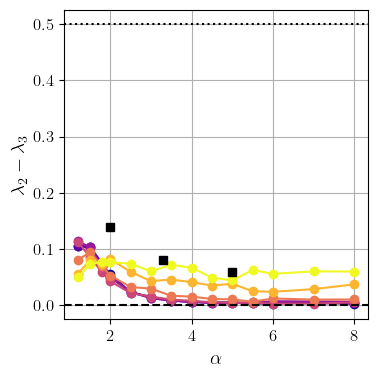

In [37]:
alphas_rods_experiments = np.array([2.0, 3.3,5.0]) #from alignment and dynamics Soft matter 2012

biaxiality_data_rods_experiments = np.array([0.21, 0.12, 0.09]) #taken from shear zone core 10-30
biaxiality_data_rods_experiments *= 2/3 # to convert to biaxiality as defined here

theta_d_rods_experiments = np.array([10.1, 8.0, 6.3])
# theta_d_rods_experiments = np.deg2rad(theta_d_rods_experiments)  # Convert degrees to radians

cmap = plt.cm.plasma
for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(4,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    
    for i_cof, cof_val in enumerate(cofs):
        plt.plot(
            aspect_ratios,
            biaxiality[i_cof, i_I, :],
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='o'
        )
    
    # Plot experimental data
    plt.plot(alphas_rods_experiments, biaxiality_data_rods_experiments, 's', color='black', label='Experiments (rods)')

    # plt.title(f"Biaxiality vs α for I = {I_val}")
    plt.xlabel("$\\alpha$")
    plt.ylabel("$\\lambda_2-\\lambda_3$")
    # plt.ylim(-0.0, 0.33)
    plt.axhline(0.0, color='k', linestyle='--', linewidth=1.5, label="Uniaxial limit")
    plt.axhline(0.5, color='k', linestyle=':', linewidth=1.5, label="Maximum biaxiality")  
    # plt.legend(title="$\\mu_p =$", bbox_to_anchor=(1.1, 1.0), fontsize=10)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"biaxiality_vs_alpha_I_{I_val}.png", dpi=300, bbox_inches='tight')
    plt.show()



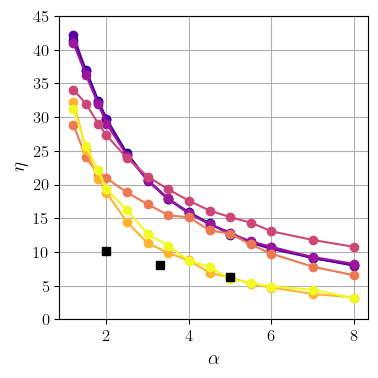

In [39]:
# print theta_D wrt the paramenters
for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(4,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    

    for i_cof, cof_val in enumerate(cofs):
        theta_shifted = np.where(theta_d[i_cof, i_I, :] < 0, theta_d[i_cof, i_I, :] + np.pi, theta_d[i_cof, i_I, :])
        plt.plot(
            aspect_ratios,
            theta_shifted*180/np.pi,
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='o'
        )
        # c = np.tan(theta_d[i_cof, i_I, :])**2
        # ell = (+1 + c) / (1-c)
        # beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
        # doi_theory_lambda = (2 + nematic_parameter[i_cof, i_I, :]) / (3 *nematic_parameter[i_cof, i_I, :])
        # theta_doi = np.atan(np.sqrt((doi_theory_lambda-1)/(doi_theory_lambda+1)))
        # plt.plot(
        #     aspect_ratios,
        #     theta_doi * 180 / np.pi,
        #     '--',
        #     color=colors[i_cof],
        #     linewidth=1.5
        # )

    # Plot experimental data
    plt.plot(alphas_rods_experiments, theta_d_rods_experiments, 's', color='black', label='Experiments (rods)')

    # # plot LE theory
    # alpha_lin = np.linspace(1.2, 8.0, 100)
    # beta_lin = (alpha_lin**2 - 1) / (alpha_lin**2 + 1)
    # theta_LE = np.atan(np.sqrt((1-beta_lin)/(1+beta_lin)))
    # plt.plot(
    #     alpha_lin,
    #     theta_LE * 180 / np.pi,
    #     'k--',
    #     label='LE theory',
    #     linewidth=2.0
    # )

    # plt.title(f"Shear angle vs α for I = {I_val}")
    plt.xlabel("$\\alpha$")
    plt.ylabel("$\\eta$")
    # plt.legend(title="$\\mu_p =$", bbox_to_anchor=(1.1, 1.0), fontsize=10)
    plt.grid(True)
    plt.ylim([0., 45])
    plt.tight_layout()
    plt.savefig(f"theta_d_vs_alpha_I_{I_val}.png", dpi=300, bbox_inches='tight')
    plt.show()



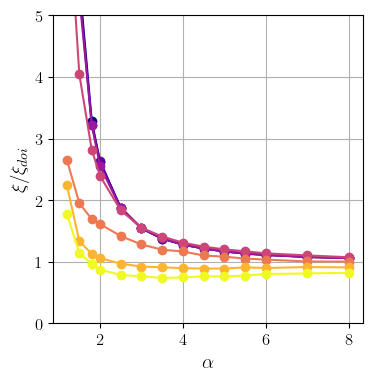

In [69]:
# derive lambda from theta_d and beta and plot it as a fucntion of alpha for the different parameters

# print theta_D wrt the paramenters
for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(4,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    
    for i_cof, cof_val in enumerate(cofs):

        c = np.tan(theta_d[i_cof, i_I, :])**2
        ell = (+1 + c) / (1-c)
        beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
        nematic_factor = (2+nematic_parameter[i_cof, i_I, :])/(3*nematic_parameter[i_cof, i_I, :])
        lambda_derived = beta * nematic_factor
        eccentricity = np.sqrt(1 - 1 / aspect_ratios**2)
        plt.plot(
            aspect_ratios,
            # ell/beta,
            ell/lambda_derived,
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='o'
        )
    
        doi_theory_lambda = beta*(2 + nematic_parameter[i_cof, i_I, :]) 
        

    # plt.title(f"Ericksen number vs epsilon for I = {I_val}")
    plt.xlabel("$\\alpha$")
    plt.ylabel("$\\xi / \\xi_{doi}$")
    # plt.legend(title="$\\mu_p =$")
    plt.grid(True)
    plt.ylim([0., 5])
    # plt.tight_layout()
    plt.savefig(f"ericksen_number_vs_epsilon_I_{I_val}.png", dpi=300, bbox_inches='tight')
    plt.show()



/tmp/ipykernel_64087/4271989379.py:2: RuntimeWarning: divide by zero encountered in divide
  first_factor = 15 / 32 / x**4
/tmp/ipykernel_64087/4271989379.py:3: RuntimeWarning: divide by zero encountered in arctanh
  second_factor = x**2 - 3 + (x**2+3) * (1- x**2) * np.arctanh(x) / x
/tmp/ipykernel_64087/4271989379.py:3: RuntimeWarning: invalid value encountered in multiply
  second_factor = x**2 - 3 + (x**2+3) * (1- x**2) * np.arctanh(x) / x
/tmp/ipykernel_64087/4271989379.py:3: RuntimeWarning: invalid value encountered in divide
  second_factor = x**2 - 3 + (x**2+3) * (1- x**2) * np.arctanh(x) / x
/tmp/ipykernel_64087/4271989379.py:4: RuntimeWarning: divide by zero encountered in divide
  third_factor = 3 - 2 * x**2 + (4 * x**2 - 3)*np.arcsin(x) / (x * np.sqrt(1 - x**2))
/tmp/ipykernel_64087/4271989379.py:4: RuntimeWarning: invalid value encountered in divide
  third_factor = 3 - 2 * x**2 + (4 * x**2 - 3)*np.arcsin(x) / (x * np.sqrt(1 - x**2))


Text(0.5, 1.0, 'Second coefficient of excluded volume as a function of eccentricity')

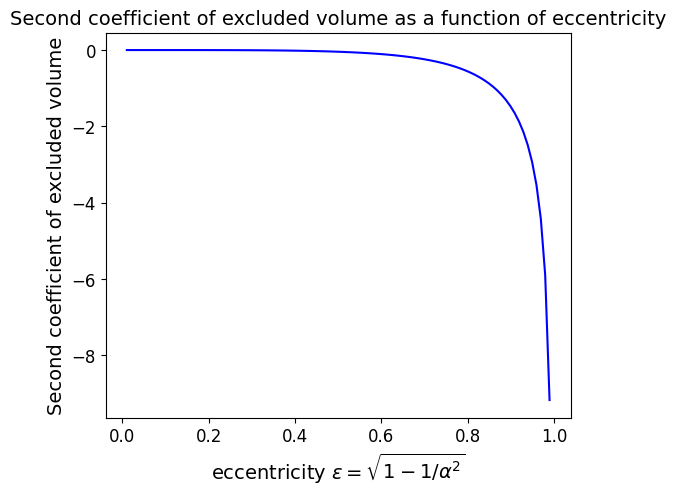

In [12]:
x = np.linspace(0, 1, 100)
plt.figure(figsize=(6, 5))
plt.plot(x, second_coeff_excluded_volume(x), label='Second coefficient of excluded volume', color='blue')
plt.xlabel('eccentricity $\\epsilon = \\sqrt{1 - 1 / \\alpha^2}$')
plt.ylabel('Second coefficient of excluded volume')
plt.title('Second coefficient of excluded volume as a function of eccentricity')


Text(0.5, 1.0, 'Eccentricity as a function of aspect ratio')

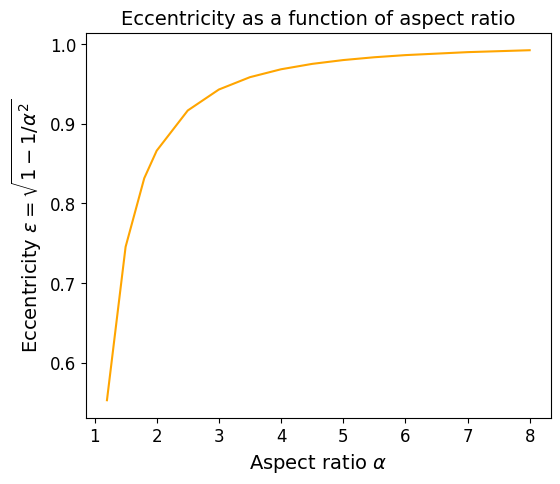

In [13]:
plt.figure(figsize=(6, 5))
plt.plot(aspect_ratios, eccentricity, label='Eccentricity', color='orange')
plt.xlabel('Aspect ratio $\\alpha$')
plt.ylabel('Eccentricity $\\epsilon = \\sqrt{1 - 1 / \\alpha^2}$')
plt.title('Eccentricity as a function of aspect ratio')

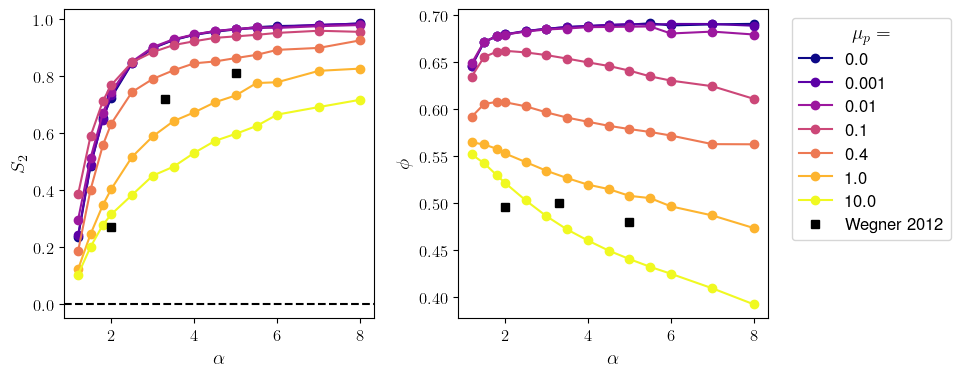

In [56]:
# plot phi as a function of aspect ratio for different cof
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
for i_cof, cof_val in enumerate(cofs):
    ax[1].plot(
        aspect_ratios,
        phis[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='o'
    )
    ax[0].plot(
        aspect_ratios,
        nematic_parameter[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='o'
    )

ax[0].plot(alpha_experimental, S2_experimental, 's', label='Wegner 2012', color='black')
ax[1].plot(alpha_experimental, phi_experimental, 's', label='Wegner 2012', color='black')
ax[0].set_xlabel(f"$\\alpha$")
ax[0].set_ylabel("$S_2$")
ax[0].axhline(0.0, color='k', linestyle='--', linewidth=1.5)
ax[1].set_xlabel(f"$\\alpha$")
ax[1].set_ylabel("$\\phi$")
fig.tight_layout()
# plt.axhline(0.0, color='k', linestyle='--', linewidth=1.5, label="Isotropic")
plt.legend(title="$\\mu_p=$", bbox_to_anchor=(1.05, 1.0), fontsize=12)
plt.savefig(f"S2_phi_vs_alpha_I_{I}.png", dpi=300, bbox_inches='tight')

<>:48: SyntaxWarning: invalid escape sequence '\e'
<>:48: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_64087/3401776914.py:48: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel("$n \ell^3$")


Power law fit parameters: a = 0.5281692546280233, b = -2.1532794476523924


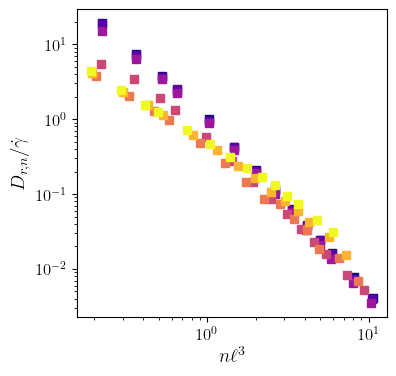

In [57]:
# plot the D_r over shear rate as function of aspect ratio for different cof
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
max_nell = 0
for i_cof, cof_val in enumerate(cofs):
    V_p = 4 * np.pi * aspect_ratios / 3  # particle volume for prolate ellipsoid
    n_ell3 = phis[i_cof, 0, :] / V_p *aspect_ratios**3
    nem_param = nematic_parameter[i_cof, 0, :]
    correction_end_end_contact = (1 + np.pi/aspect_ratios) + (2*np.pi/aspect_ratios - 1) * nem_param**2

    max_nell = max(max_nell, np.max(n_ell3))

    # ax[0].loglog(
    #     aspect_ratios,
    #     D_r[i_cof, 0, :]/shear_rates[i_cof, 0, :],
    #     's',
    #     label=f"{cof_val}",
    #     color=colors[i_cof]
    # )

    ax.loglog(
        n_ell3,
        D_r[i_cof, 0, :] * correction_end_end_contact**2/shear_rates[i_cof, 0, :],
        's',
        label=f"{cof_val}",
        color=colors[i_cof]
    )
# Power law model: y = a * x^b
def power_law(x, a, b):
    return a * x**b

correction_end_end_contact = (1 + np.pi/aspect_ratios) + (2*np.pi/aspect_ratios - 1) * nematic_parameter[0,0,:]**2

# Fit the data
popt, _ = spo.curve_fit(
    power_law,
    n_ell3,
    D_r[0, 0, :] * correction_end_end_contact**2 / shear_rates[0, 0, :],
    p0=[1, 1]  # Initial guess for a and b
)

n_ell_fit = np.linspace(0, max_nell, 100)

# Plot
# ax.plot(n_ell_fit, power_law(n_ell_fit, *popt), 'k--', label='Power law fit (frictionless)', linewidth=2)

print(f"Power law fit parameters: a = {popt[0]}, b = {popt[1]}")

ax.set_xlabel("$n \ell^3$")
ax.set_ylabel("$D_{r,n}/ \\dot \\gamma$")
fig.savefig(f"D_r_over_shear_vs_n_ell3_I_{I}.png", dpi=300, bbox_inches='tight')

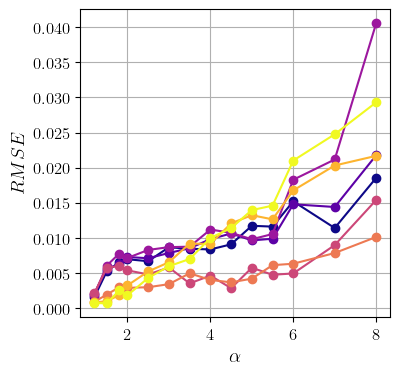

In [58]:
# plot rmse as a function of aspect ratio for different cof
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
for i_cof, cof_val in enumerate(cofs):
    ax.plot(
        aspect_ratios,
        rmse[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='o'
    )

ax.set_xlabel(f"$\\alpha$")
ax.set_ylabel("$RMSE$")
ax.grid(True)
plt.savefig(f"rmse_vs_alpha_I_{I}.png", dpi=300, bbox_inches='tight')


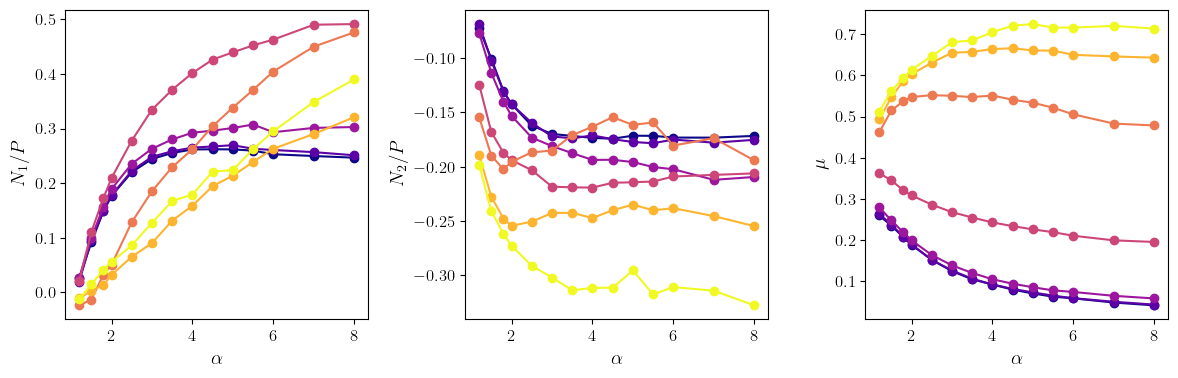

In [68]:
#plot n1_diff and n2_diff as a function of aspect ratio for different cof
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for i_cof, cof_val in enumerate(cofs):
    ax[0].plot(
        aspect_ratios,
        n1_diff[i_cof, 0, :]/p_yy[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='o'
    )
    ax[1].plot(
        aspect_ratios,
        n2_diff[i_cof, 0, :]/p_yy[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='o'
    )
    ax[2].plot(
        aspect_ratios,
        p_xy[i_cof, 0, :]/p_yy[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='o'
    )


ax[0].set_xlabel(f"$\\alpha$")
ax[0].set_ylabel("$N_1/P$")
ax[1].set_xlabel(f"$\\alpha$")
ax[1].set_ylabel("$N_2/P$")
ax[2].set_xlabel(f"$\\alpha$")
ax[2].set_ylabel("$\\mu$")
fig.tight_layout()


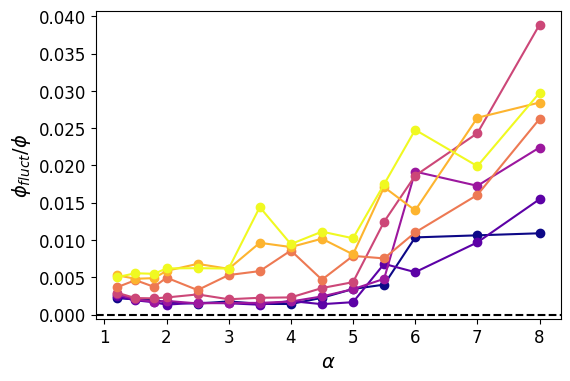

In [18]:
# plot fluctuations of phi as a function of aspect ratio for different cof
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
for i_cof, cof_val in enumerate(cofs):
    ax.plot(
        aspect_ratios,
        phi_fluctuations[i_cof, 0, :]/phis[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='o'
    )
ax.set_xlabel(f"$\\alpha$")
ax.set_ylabel("$\\phi_{fluct}/\\phi$")
ax.axhline(0.0, color='k', linestyle='--', linewidth=1.5)


Text(0.5, 0, '$\\alpha$')

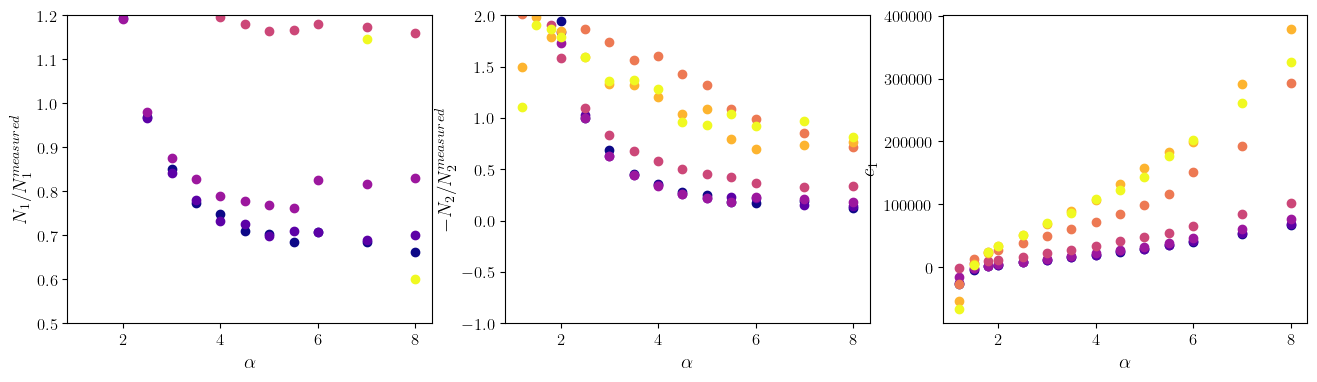

In [59]:
# for each alpha as a function of cof fit the stress with the pressure and then check the predicted N_1 and N_2 against the computed once

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for i_cof, cof in enumerate(cofs):
    const_fits = np.zeros((len(aspect_ratios)))
    n1s_predicted = np.zeros((len(aspect_ratios)))
    n2s_predicted = np.zeros((len(aspect_ratios)))
    n1s_measured = np.zeros((len(aspect_ratios)))
    n2s_measured = np.zeros((len(aspect_ratios)))
    shear_stress_measured = np.zeros((len(aspect_ratios)))
    shear_stress_predicted = np.zeros((len(aspect_ratios)))

    for i_alpha, alpha in enumerate(aspect_ratios):
        n1_measured = n1_diff[i_cof, 0, i_alpha] / p_yy[i_cof, 0, i_alpha]
        n2_measured = n2_diff[i_cof, 0, i_alpha] / p_yy[i_cof, 0, i_alpha]
        phi_dense = phis[i_cof, 0, i_alpha]
        S2 = S2_tensor[i_cof, 0, i_alpha, :, :]
        S4 = S4_tensor[i_cof, 0, i_alpha, :, :, :, :]

        shear_rate = shear_rates[i_cof, 0, i_alpha]
        strain_tensor = 0.5*np.array([[0, 1, 0], [1, 0, 0], [0, 0, 0]]) * shear_rate 
        
        T1 = np.einsum('ijkl, kl->ij', S4, strain_tensor)  # 2nd order tensor
        T2 = np.einsum('ijkl, kl->ij', S4, S2)  
        T3 = S2@S2 
        T_elastic = -(T3 + phi_dense*S2/3 - T2)
        # const_fit = - p_yy[i_cof, 0, i_alpha] / total_stress[0, 0]
        # const_fits[i_alpha] = const_fit
        # stress_model = const_fit * total_stress

        b = np.array([
            p_yy[i_cof, 0, i_alpha],   # measured sigma_yy
            p_xy[i_cof, 0, i_alpha]    # measured sigma_xy
        ])

        A = np.array([
            [T1[1, 1], T_elastic[1, 1]],  # sigma_yy = row 1, col 1
            [T1[0, 1], T_elastic[0, 1]]   # sigma_xy = row 0, col 1 (symm)
        ])

        c1, c2 = np.linalg.solve(A, b)

        stress_model = c1 * T1 + c2 * T_elastic
        const_fits[i_alpha] = c1

        n1_predicted = (stress_model[0,0] - stress_model[1,1]) / p_yy[i_cof, 0, i_alpha]
        n2_predicted = (stress_model[1,1] - stress_model[2,2]) / p_yy[i_cof, 0, i_alpha] 

        n1s_predicted[i_alpha] = n1_predicted
        n2s_predicted[i_alpha] = n2_predicted
        n1s_measured[i_alpha] = n1_measured
        n2s_measured[i_alpha] = n2_measured
        shear_stress_measured[i_alpha] = p_xy[i_cof, 0, i_alpha]
        shear_stress_predicted[i_alpha] = stress_model[0, 1]

    # ax[0].plot(
    #     aspect_ratios,
    #     n1s_predicted,
    #     '-o',
    #     color=colors[i_cof],)
    # ax[1].plot(
    #     aspect_ratios,
    #     n2s_predicted,
    #     '-o',
    #     color=colors[i_cof],)
    # ax[2].plot(
    #     aspect_ratios,
    #     const_fits,
    #     '-o',
    #     color=colors[i_cof],)
    # ax[3].plot(
    #     aspect_ratios,
    #     shear_stress_predicted,
    #     '-o',
    #     color=colors[i_cof],)

    ax[0].plot(
        aspect_ratios,
        n1s_predicted/n1s_measured,
        'o',
        color=colors[i_cof],)
    ax[1].plot(
        aspect_ratios,
        -n2s_predicted/ n2s_measured,
        'o',
        color=colors[i_cof],)
    ax[2].plot(
        aspect_ratios,
        const_fits,
        'o',
        color=colors[i_cof],)

ax[0].set_ylim(0.5, 1.2)
ax[1].set_ylim(-1, 2)
ax[0].set_ylabel("$N_1/N_1^{measured}$")
ax[1].set_ylabel("$-N_2/N_2^{measured}$")
ax[2].set_ylabel("$c_1$")
ax[0].set_xlabel("$\\alpha$")
ax[1].set_xlabel("$\\alpha$")
ax[2].set_xlabel("$\\alpha$")



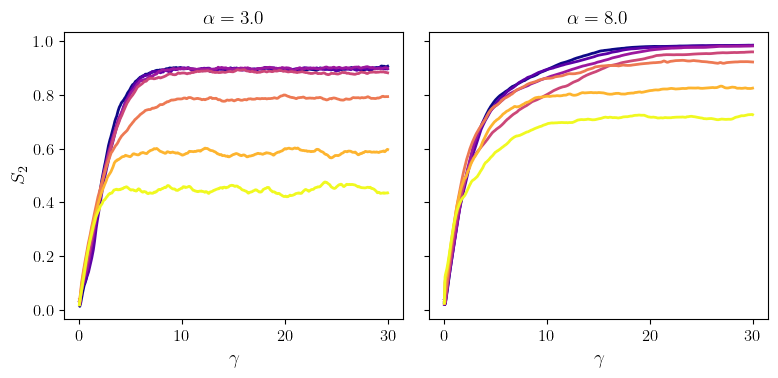

In [60]:
# plot s2 over time for a fixd alpha and different cofs
alpha_indexs = [5, 13]
alpha_values = aspect_ratios[alpha_indexs]

cmap = plt.cm.plasma
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]


fig, ax = plt.subplots(1, len(alpha_values), figsize=(4*len(alpha_values), 4), sharey=True)
for i, alpha_index in enumerate(alpha_indexs):
    for i_cof, cof_val in enumerate(cofs):
        # remove trailing zeros to arrays
        gamma = strains[i_cof, 0, alpha_index, :]
        S2_t = S2_over_time[i_cof, 0, alpha_index, :]

        gamma = np.where(gamma != 0, gamma, np.nan)  # Replace zeros with NaN for better plotting
        S2_t = np.where(S2_t != 0, S2_t, np.nan)  # Replace zeros with NaN for better plotting

        ax[i].plot(
            gamma,
            S2_t,
            label=f"{cof_val}",
            color=colors_cof[i_cof],
            linewidth = 2, 
            # marker='o'
        )

    ax[i].set_title(f"$\\alpha = {alpha_values[i]}$")
    ax[i].set_xlabel("$\\gamma$")

ax[0].set_ylabel("$S_2$")
fig.tight_layout()
fig.savefig(f"S2_over_time_vs_gamma_alpha.png", dpi=300, bbox_inches='tight')

<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:44: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_64087/2733262177.py:44: SyntaxWarning: invalid escape sequence '\l'
  ax[0].set_ylabel("$\langle [\mathbf{u}(t) \cdot \mathbf{u}(0)]^2  \\rangle  $")


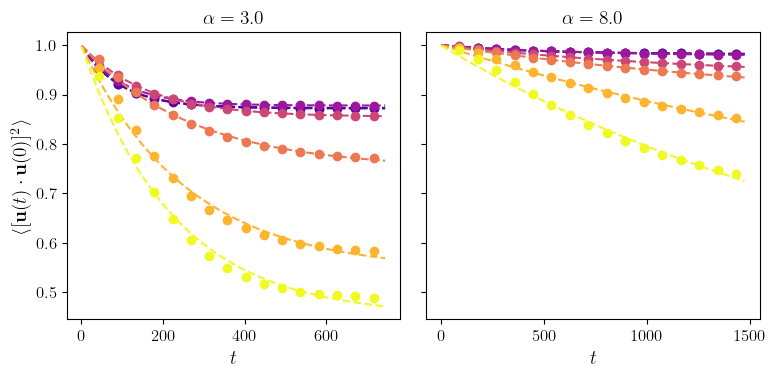

In [67]:
# plot oacf over time

def model_decay(t, tau_r, A_infty):
    return A_infty + (1 - A_infty) * np.exp(-t / tau_r)



alpha_indexs = [5, 13]
alpha_values = aspect_ratios[alpha_indexs]

cmap = plt.cm.plasma
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]
n_plots = len(alpha_indexs)
fig, ax = plt.subplots(1, n_plots, figsize=(4*n_plots, 4), sharey=True)

for i, alpha_index in enumerate(alpha_indexs):
    for i_cof, cof_val in enumerate(cofs): #(cofs):
        # remove trailing zeros to arrays
        t = times[i_cof, 0, alpha_index, :]
        corr = oacf[i_cof, 0, alpha_index, :]

        t = np.where(t != 0, t, np.nan)  # Replace zeros with NaN for better plotting
        corr = np.where(corr != 0, corr, np.nan)  # Replace zeros with NaN for better plotting

        ax[i].plot(
            t[::30],
            corr[::30],
            'o',
            label=f"{cof_val}",
            color=colors_cof[i_cof]
            # linewidth = 2, 
        )
        # plot the fitted model
        ax[i].plot(
            t, 
            model_decay(t, tau_r[i_cof, 0, alpha_index], A_infty[i_cof, 0, alpha_index]),
            color=colors_cof[i_cof],
            linestyle='--'
        )

    ax[i].set_title(f"$\\alpha = {alpha_values[i]}$")
    ax[i].set_xlabel("$t$")

ax[0].set_ylabel("$\langle [\mathbf{u}(t) \cdot \mathbf{u}(0)]^2  \\rangle  $")
fig.tight_layout()
fig.savefig(f"oacf_vs_time_alpha.png", dpi=300, bbox_inches='tight')


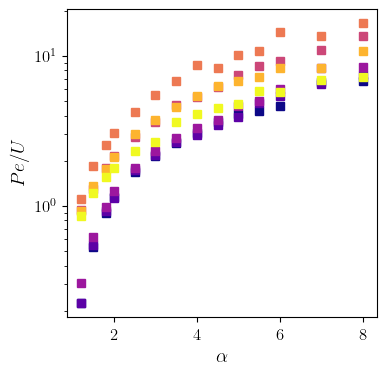

In [18]:
cmap = plt.cm.plasma
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]

# plot the Peclet number with the measured D_rn
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
for i_cof, cof_val in enumerate(cofs):
    Pe = shear_rates[i_cof, 0, :] / (D_r[i_cof, 0, :])
    shear_at_amgle = beta* np.sin(2 *theta_d[i_cof, 0, :]) 

    ax.plot(
        aspect_ratios,
        Pe/(U_fitted[i_cof, 0, :]),  # factor 3 accounts for the use of cos(2*theta) instead of P_2(cos(theta))
        's',
        label=f"{cof_val}",
        color=colors_cof[i_cof]
    )
# ax.set_xlabel(f"$\\alpha$")
ax.set_xlabel("$\\alpha$")
ax.set_ylabel("$Pe/U$")
ax.set_yscale('log')
# ax.set_ylim(0, 100)
fig.savefig(f"Pe_vs_alpha_I_{I}.png", dpi=300, bbox_inches='tight')

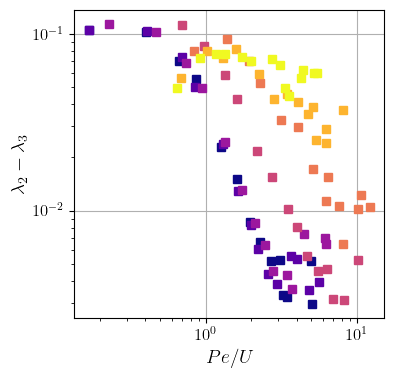

In [35]:
# plot pe against biaxiality
cmap = plt.cm.plasma
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
for i_cof, cof_val in enumerate(cofs):
    Pe =  shear_rates[i_cof, 0, :] / (D_r[i_cof, 0, :]) / (4/3*U_fitted[i_cof, 0, :])
    ax.plot(
        Pe,
        biaxiality[i_cof, 0, :],
        's',
        label=f"{cof_val}",
        color=colors_cof[i_cof]
    )

ax.set_ylabel("$\\lambda_2 - \\lambda_3$")
ax.set_xlabel("$Pe/U$")
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True)

In [25]:
biaxiality

array([[[0.10548574, 0.103119  , 0.07065609, 0.05574535, 0.02277098,
         0.01507689, 0.0085815 , 0.00664165, 0.00517322, 0.00521351,
         0.00333111, 0.00322958, 0.00517122, 0.00295524]],

       [[0.10544668, 0.10399651, 0.07456335, 0.05045773, 0.0237829 ,
         0.01295057, 0.00832755, 0.00601955, 0.00439763, 0.00383442,
         0.00549967, 0.00530938, 0.00354639, 0.0039192 ]],

       [[0.11409344, 0.10321808, 0.06847186, 0.04937083, 0.02444544,
         0.01303368, 0.0085016 , 0.00642177, 0.00457335, 0.0043149 ,
         0.00360285, 0.00735569, 0.00700375, 0.00646075]],

       [[0.11311741, 0.08572456, 0.05870263, 0.04290785, 0.02174699,
         0.01551823, 0.01021998, 0.00802075, 0.0055186 , 0.00456068,
         0.00467018, 0.00316273, 0.00312248, 0.0052489 ]],

       [[0.08068231, 0.09437114, 0.07076123, 0.05293314, 0.03263511,
         0.02965638, 0.01708736, 0.01556951, 0.01133995, 0.01058187,
         0.0064674 , 0.01221716, 0.01026209, 0.01047132]],

       [[0